# Python Examples

This page provides comprehensive examples of using **unifres** with various model types in Python.

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

from unifres import fresiduals, ffplot, fredplot

Environment initialized.


## Example 1: logistic regression

### Detecting missing polynomial terms

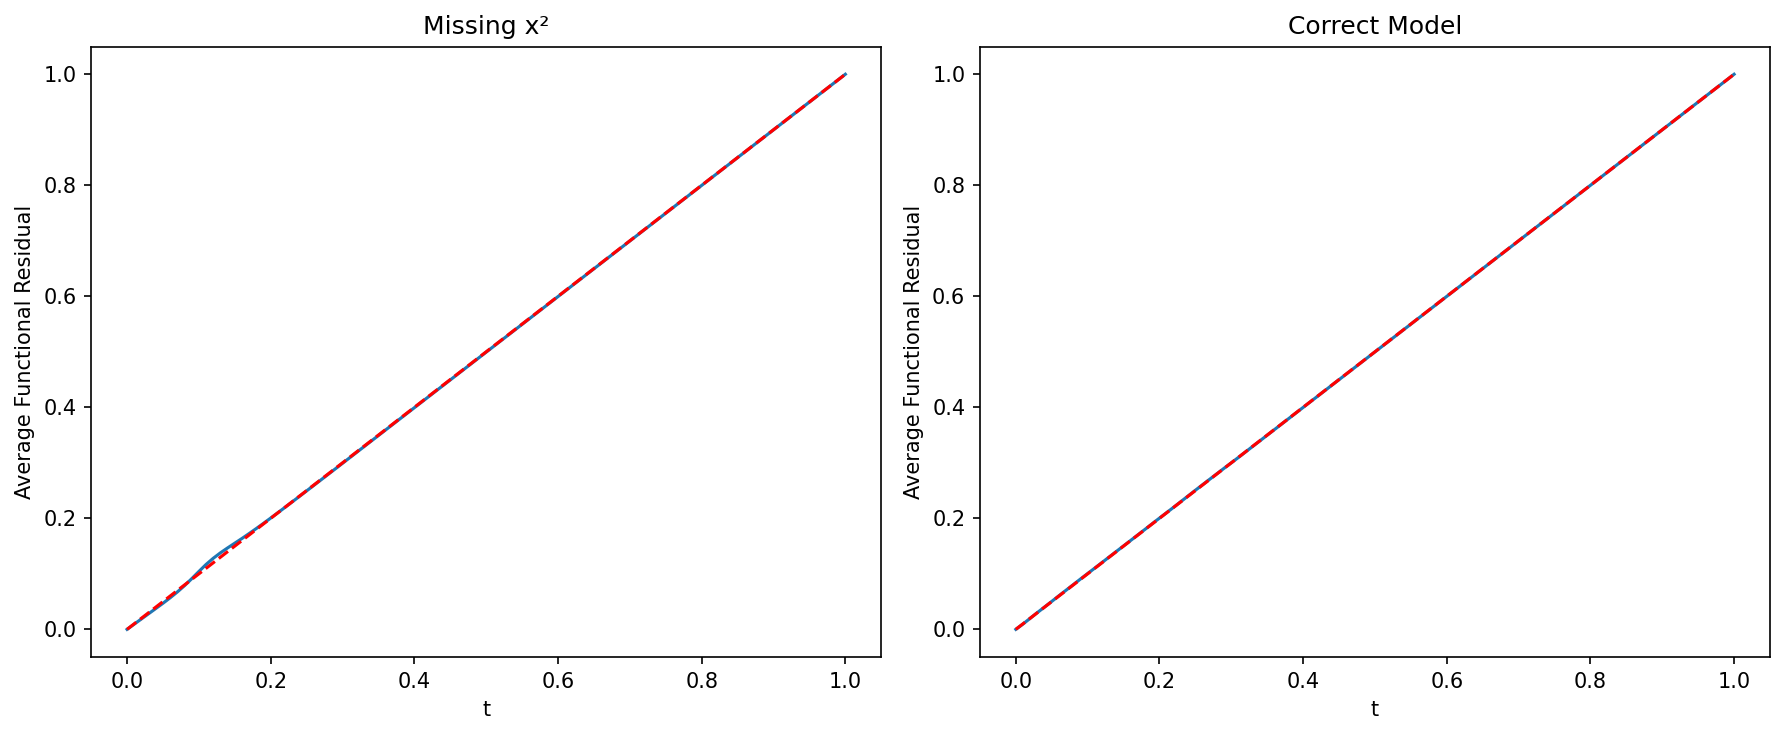

In [2]:
# Generate data with a quadratic relationship
np.random.seed(1217)
n = 1000
x = np.random.normal(size=n)
z = 1 - 2*x + 3*x**2 + np.random.logistic(size=n)
y = np.where(z > 0, 1, 0)

# Fit incorrect model (missing x²)
X_wrong = sm.add_constant(x)
model_wrong = sm.GLM(y, X_wrong, family=sm.families.Binomial()).fit()

# Fit correct model
X_correct = sm.add_constant(np.column_stack([x, x**2]))
model_correct = sm.GLM(y, X_correct, family=sm.families.Binomial()).fit()

# Compare with function-function plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ffplot(model_wrong, ax=axes[0])
axes[0].set_title("Missing x²")
ffplot(model_correct, ax=axes[1])
axes[1].set_title("Correct Model")
plt.tight_layout()
plt.show()

### Using FRED plots

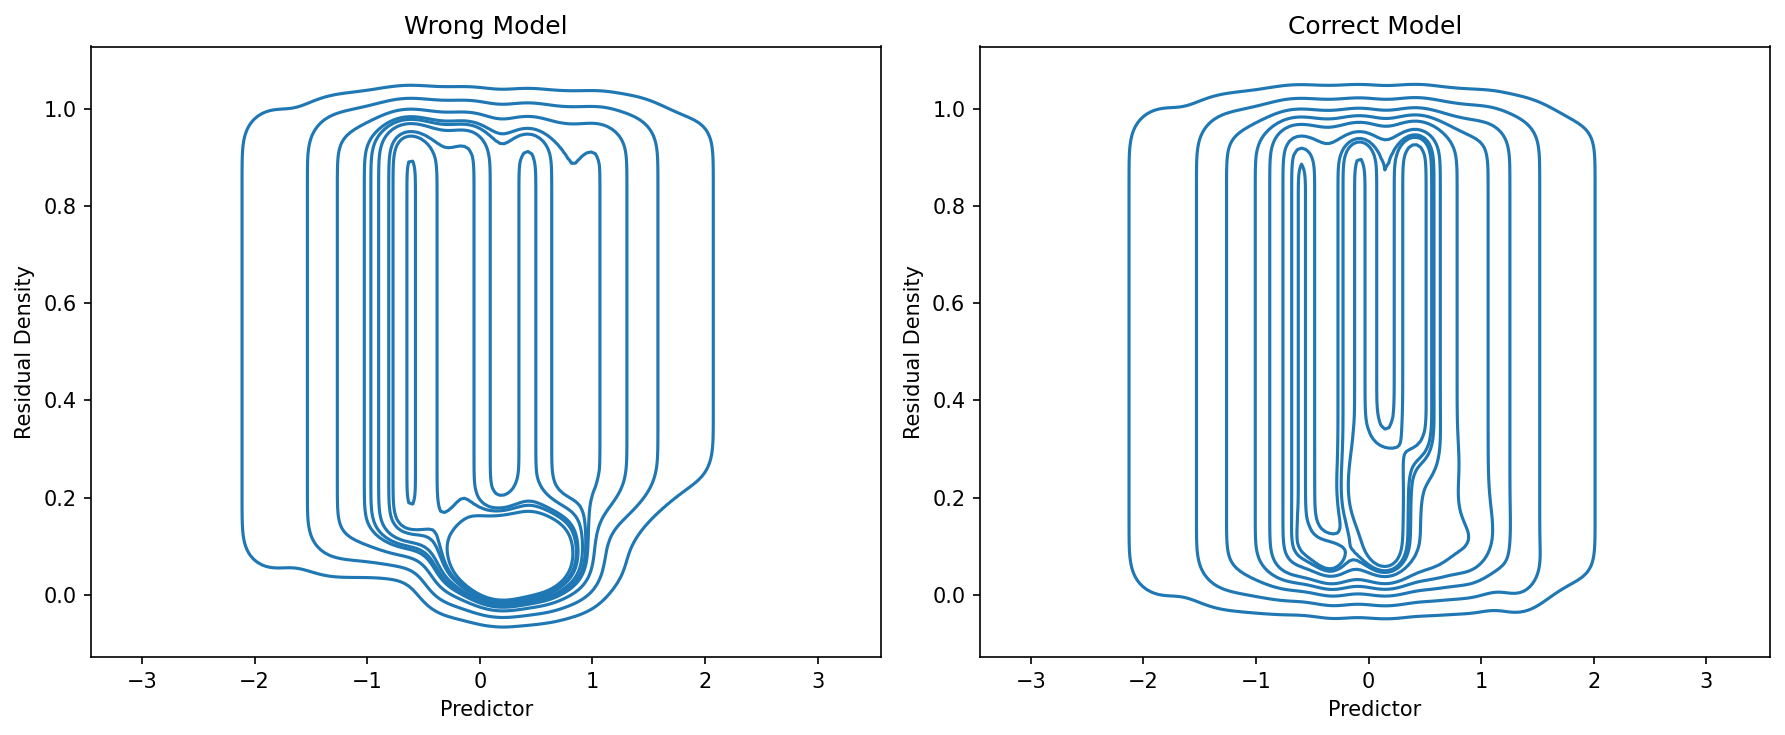

In [3]:
# FRED plots show where the model fails
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fredplot(model_wrong, x, type="kde", ax=axes[0])
axes[0].set_title("Wrong Model")

fredplot(model_correct, x, type="kde", ax=axes[1])
axes[1].set_title("Correct Model")

plt.tight_layout()
plt.show()

---

## Example 2: Poisson regression

### Count data analysis

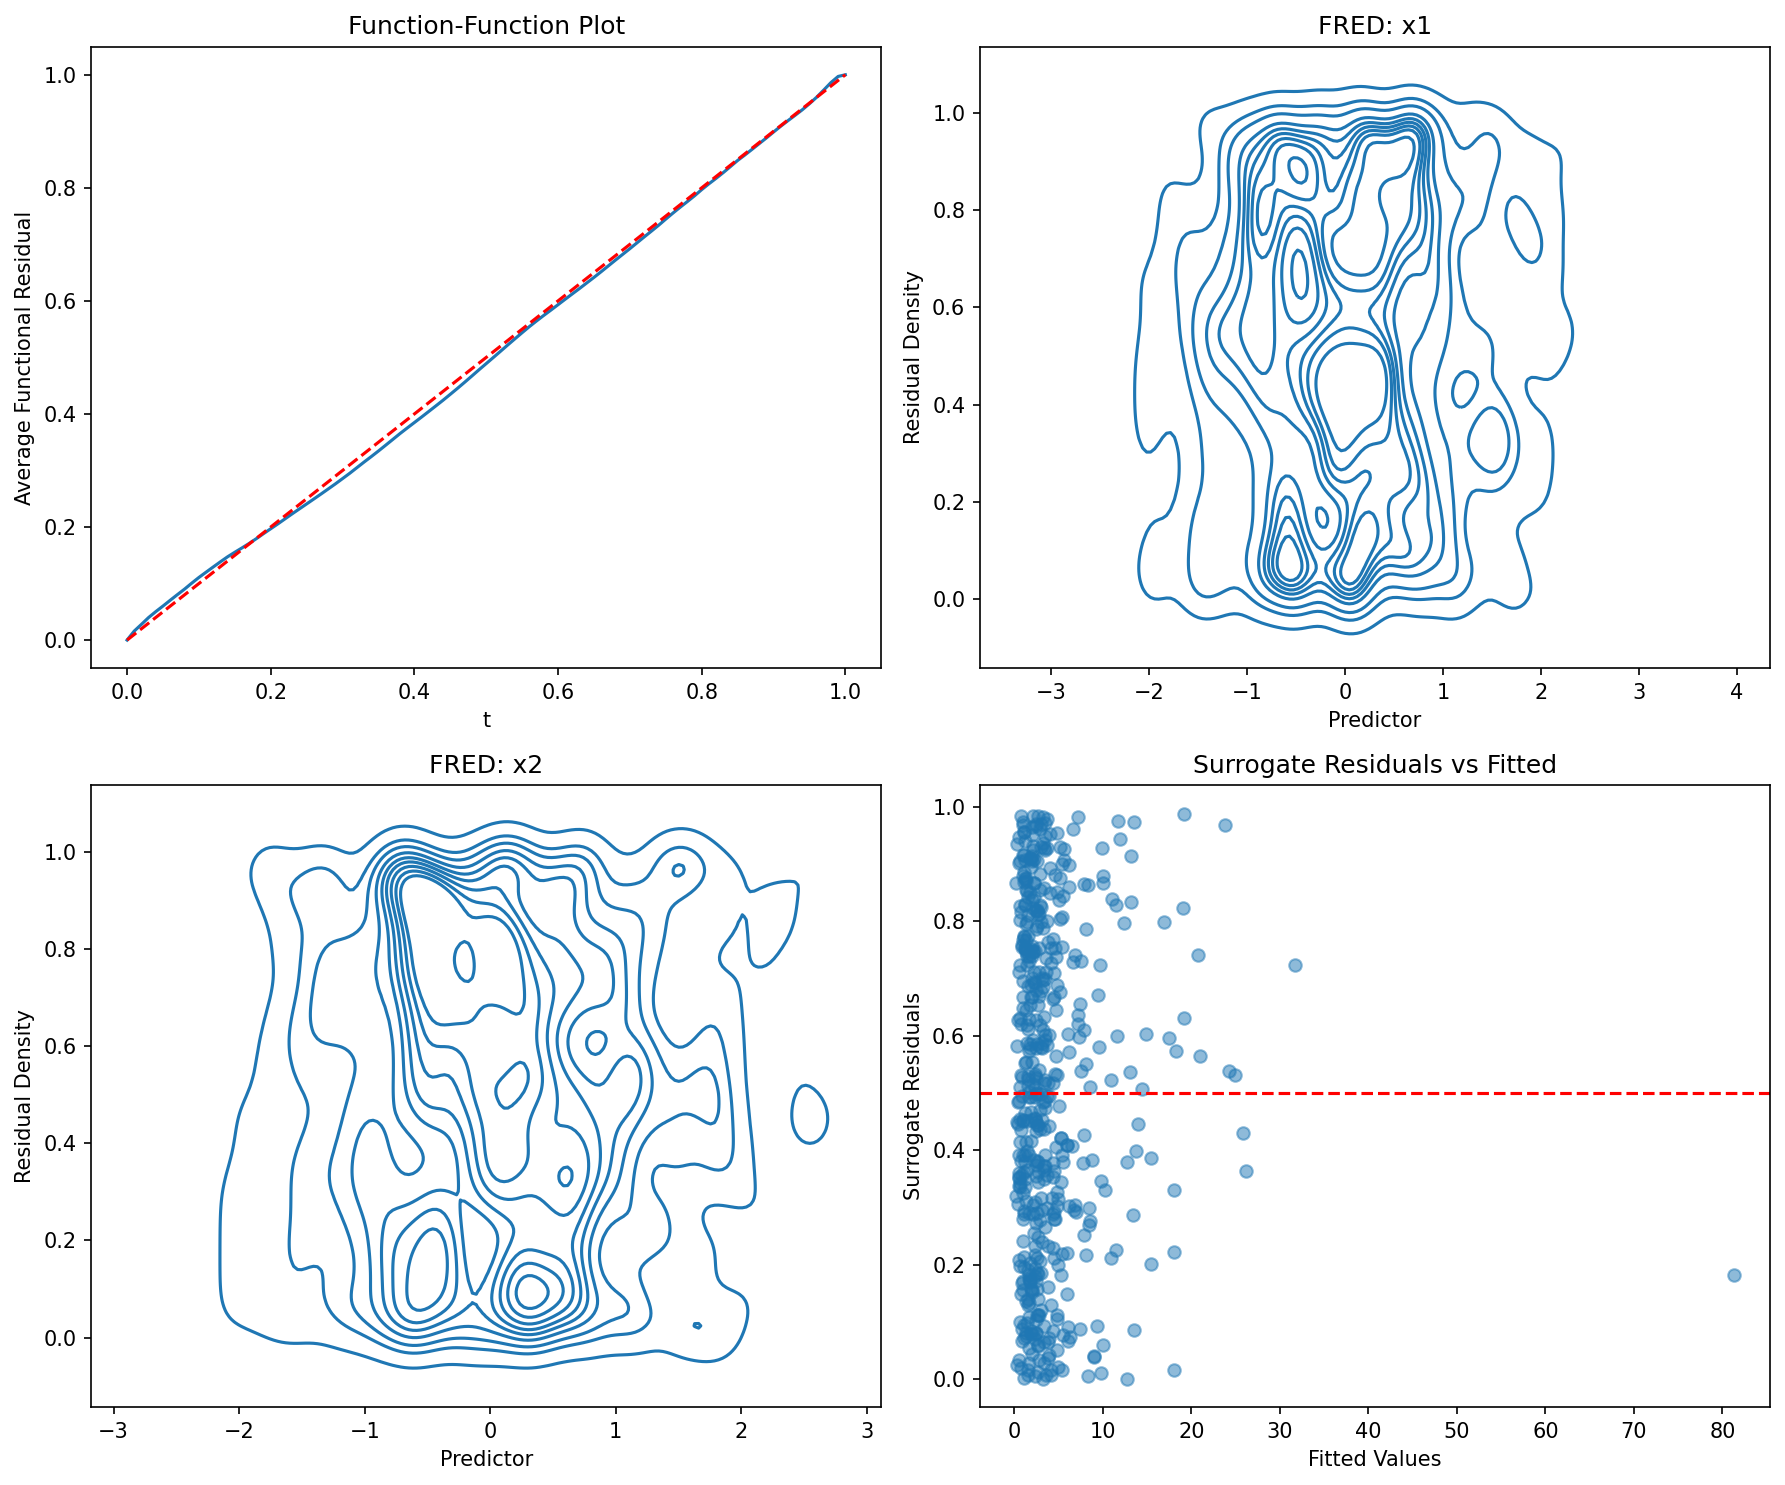

In [4]:
# Simulate count data
np.random.seed(42)
n = 500
x1 = np.random.normal(size=n)
x2 = np.random.normal(size=n)
lambda_ = np.exp(1 + 0.5*x1 + 0.8*x2)
y = np.random.poisson(lambda_)

# Fit model
X = sm.add_constant(np.column_stack([x1, x2]))
model = sm.GLM(y, X, family=sm.families.Poisson()).fit()

# Check model adequacy
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ffplot(model, ax=axes[0, 0])
axes[0, 0].set_title("Function-Function Plot")

fredplot(model, x1, type="kde", ax=axes[0, 1])
axes[0, 1].set_title("FRED: x1")

fredplot(model, x2, type="kde", ax=axes[1, 0])
axes[1, 0].set_title("FRED: x2")

# Surrogate residual plot
surr_res = fresiduals(model, type="surrogate")
axes[1, 1].scatter(model.fittedvalues, surr_res, alpha=0.5)
axes[1, 1].axhline(y=0.5, color='r', linestyle='--')
axes[1, 1].set_xlabel("Fitted Values")
axes[1, 1].set_ylabel("Surrogate Residuals")
axes[1, 1].set_title("Surrogate Residuals vs Fitted")

plt.tight_layout()
plt.show()

### Detecting overdispersion

In [ ]:
# Generate overdispersed count data
np.random.seed(123)
n = 500
x = np.random.normal(size=n)
mu = np.exp(1 + x)
# Add overdispersion via negative binomial
size = 2
prob = size / (size + mu)
y = np.random.negative_binomial(size, prob)

# Fit Poisson (wrong)
X = sm.add_constant(x)
model_pois = sm.GLM(y, X, family=sm.families.Poisson()).fit()

# Fit Negative Binomial (correct)
model_nb = sm.NegativeBinomial(y, X).fit(disp=0)

# Compare
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ffplot(model_pois, ax=axes[0])
axes[0].set_title("Poisson")
ffplot(model_nb, ax=axes[1])
axes[1].set_title("Negative Binomial")
plt.tight_layout()
plt.show()

---

## Example 3: negative binomial regression

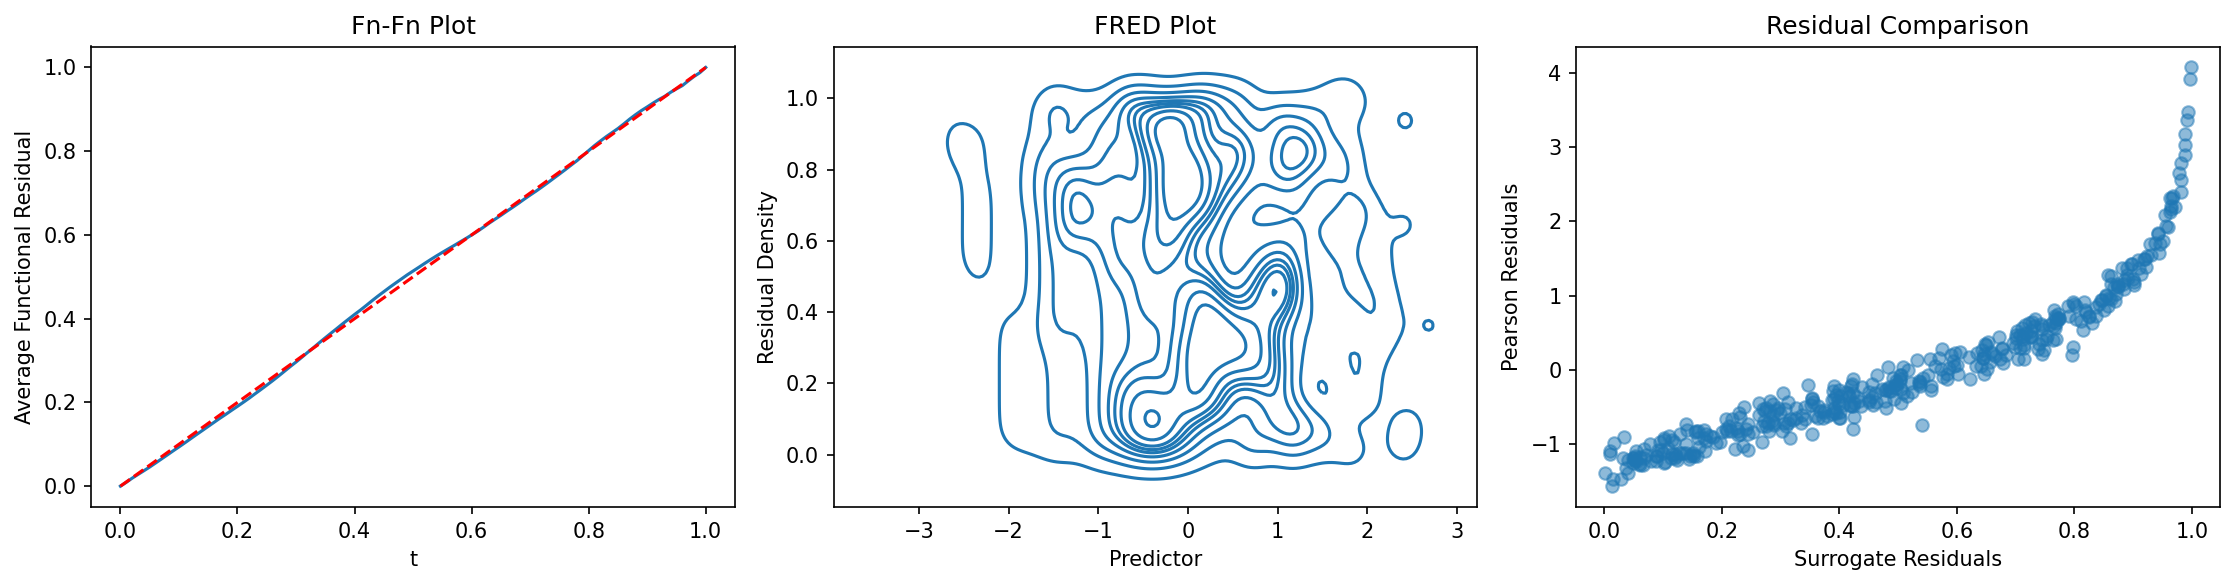

In [6]:
# Generate negative binomial data
np.random.seed(2024)
n = 400
x = np.random.normal(size=n)
mu = np.exp(1 + 0.5*x)
size = 3
prob = size / (size + mu)
y = np.random.negative_binomial(size, prob)

# Fit model using discrete NegativeBinomial
X = sm.add_constant(x)
model_nb = sm.NegativeBinomial(y, X).fit(disp=0)

# Diagnostics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ffplot(model_nb, ax=axes[0])
axes[0].set_title("Fn-Fn Plot")

fredplot(model_nb, x, type="kde", ax=axes[1])
axes[1].set_title("FRED Plot")

# Compare surrogate to traditional residuals
surr_res = fresiduals(model_nb, type="surrogate")
pearson_res = model_nb.resid_pearson
axes[2].scatter(surr_res, pearson_res, alpha=0.5)
axes[2].set_xlabel("Surrogate Residuals")
axes[2].set_ylabel("Pearson Residuals")
axes[2].set_title("Residual Comparison")

plt.tight_layout()
plt.show()

---

## Example 4: using Pandas DataFrames

### Working with real-world data structure

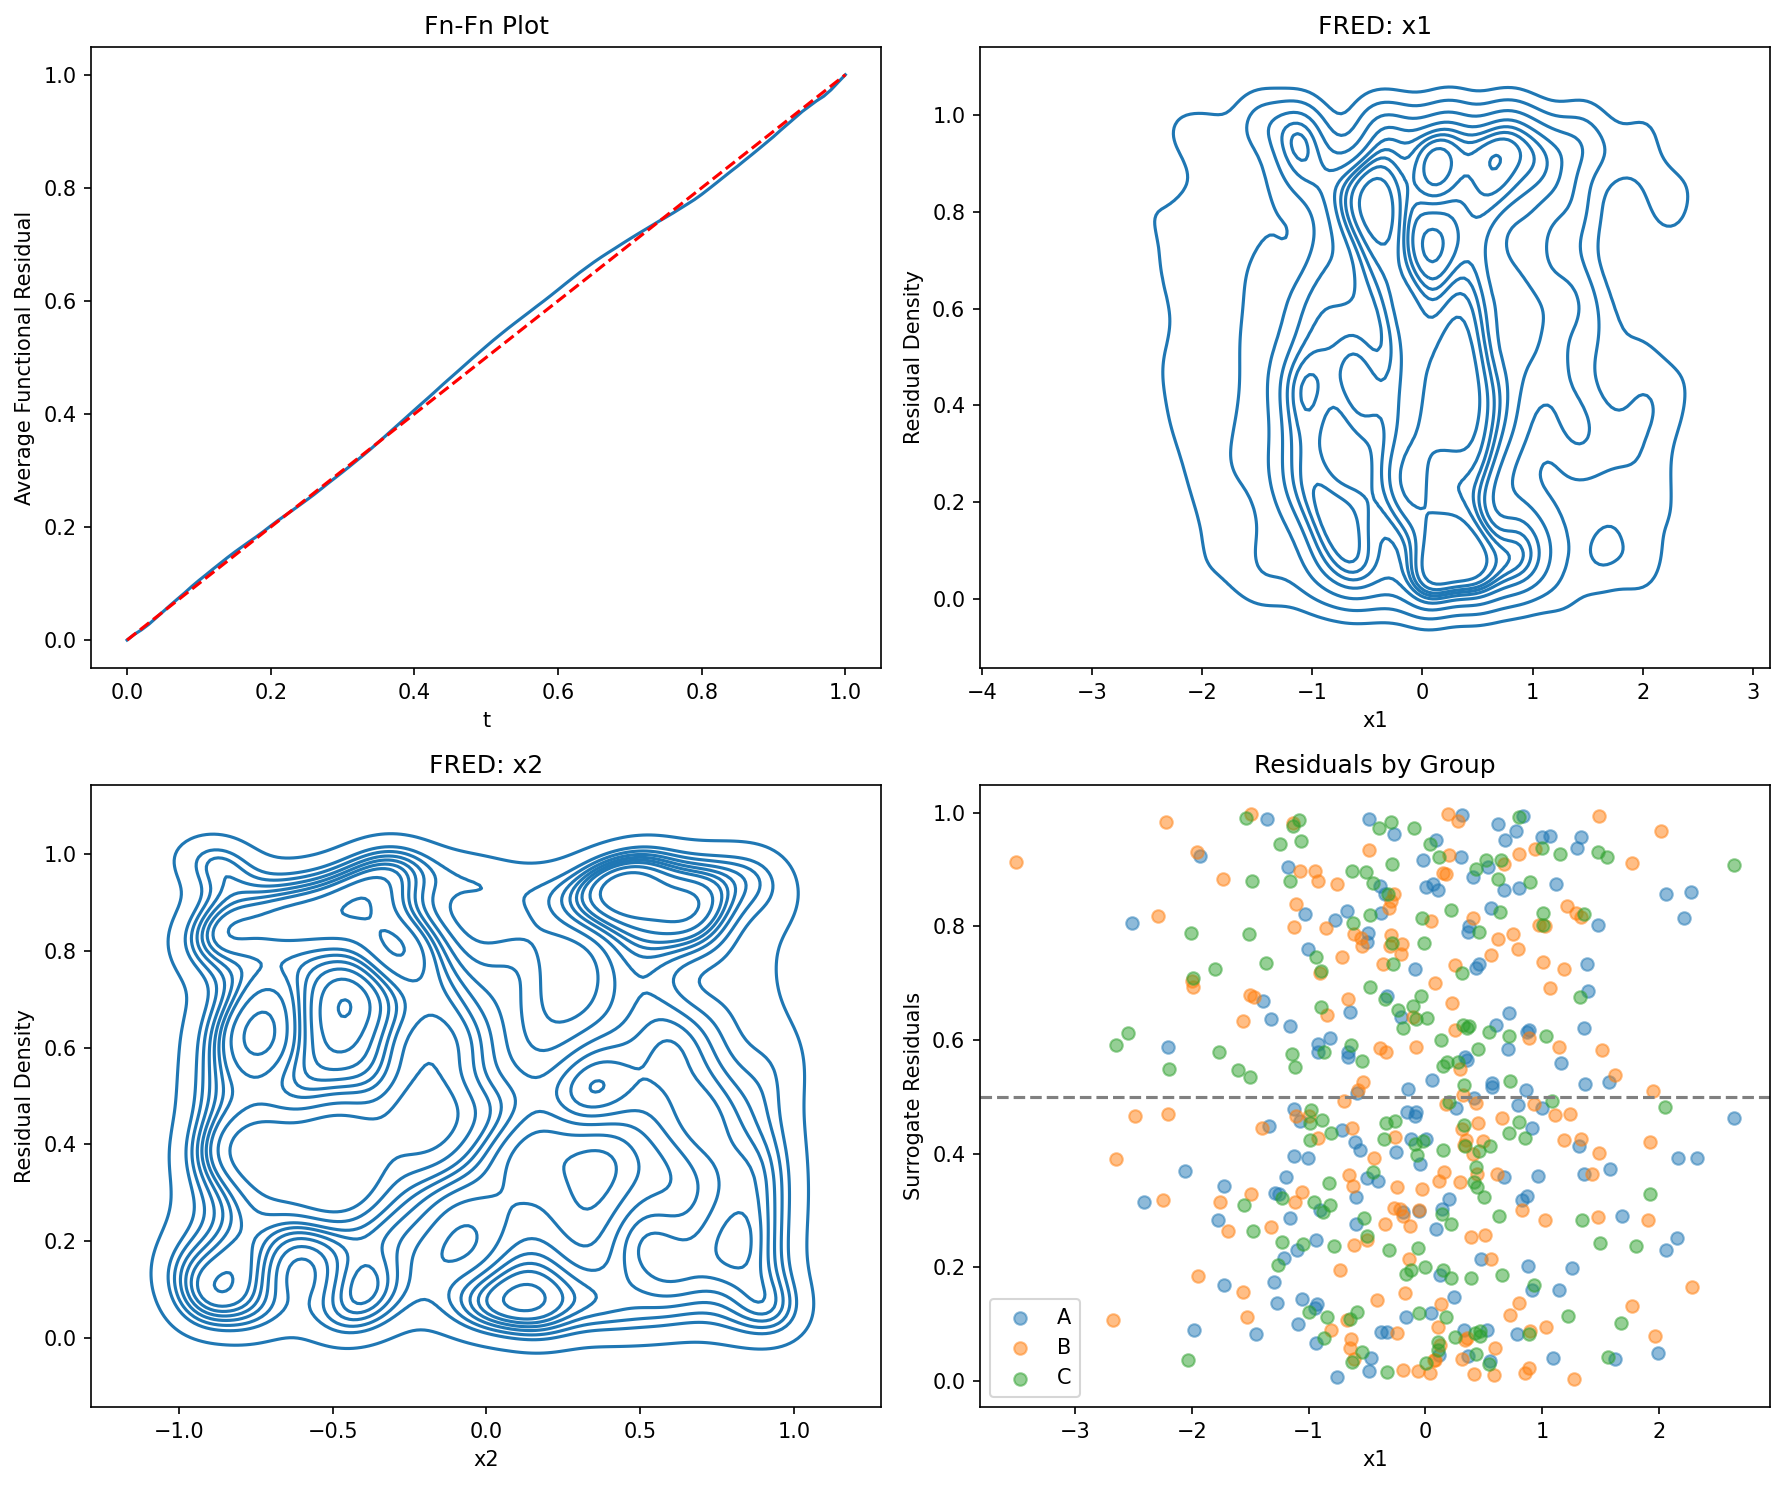

In [7]:
# Create a DataFrame
np.random.seed(555)
n = 500
df = pd.DataFrame({
    'x1': np.random.normal(size=n),
    'x2': np.random.uniform(-1, 1, size=n),
    'group': np.random.choice(['A', 'B', 'C'], size=n)
})

# Generate outcome
eta = 1 + 0.5*df['x1'] - 0.3*df['x2']
df['y'] = np.random.poisson(np.exp(eta))

# Fit model using formula
model = smf.glm('y ~ x1 + x2', data=df, family=sm.families.Poisson()).fit()

# Diagnostics with DataFrame columns
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ffplot(model, ax=axes[0, 0])
axes[0, 0].set_title("Fn-Fn Plot")

fredplot(model, df['x1'].values, ax=axes[0, 1])
axes[0, 1].set_xlabel("x1")
axes[0, 1].set_title("FRED: x1")

fredplot(model, df['x2'].values, ax=axes[1, 0])
axes[1, 0].set_xlabel("x2")
axes[1, 0].set_title("FRED: x2")

# Residuals by group
surr_res = fresiduals(model, type="surrogate")
for group in ['A', 'B', 'C']:
    mask = df['group'] == group
    axes[1, 1].scatter(df.loc[mask, 'x1'], surr_res[mask],
                      label=group, alpha=0.5)
axes[1, 1].axhline(y=0.5, color='gray', linestyle='--')
axes[1, 1].set_xlabel("x1")
axes[1, 1].set_ylabel("Surrogate Residuals")
axes[1, 1].set_title("Residuals by Group")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

---

## Example 5: model comparison

### Comparing nested models

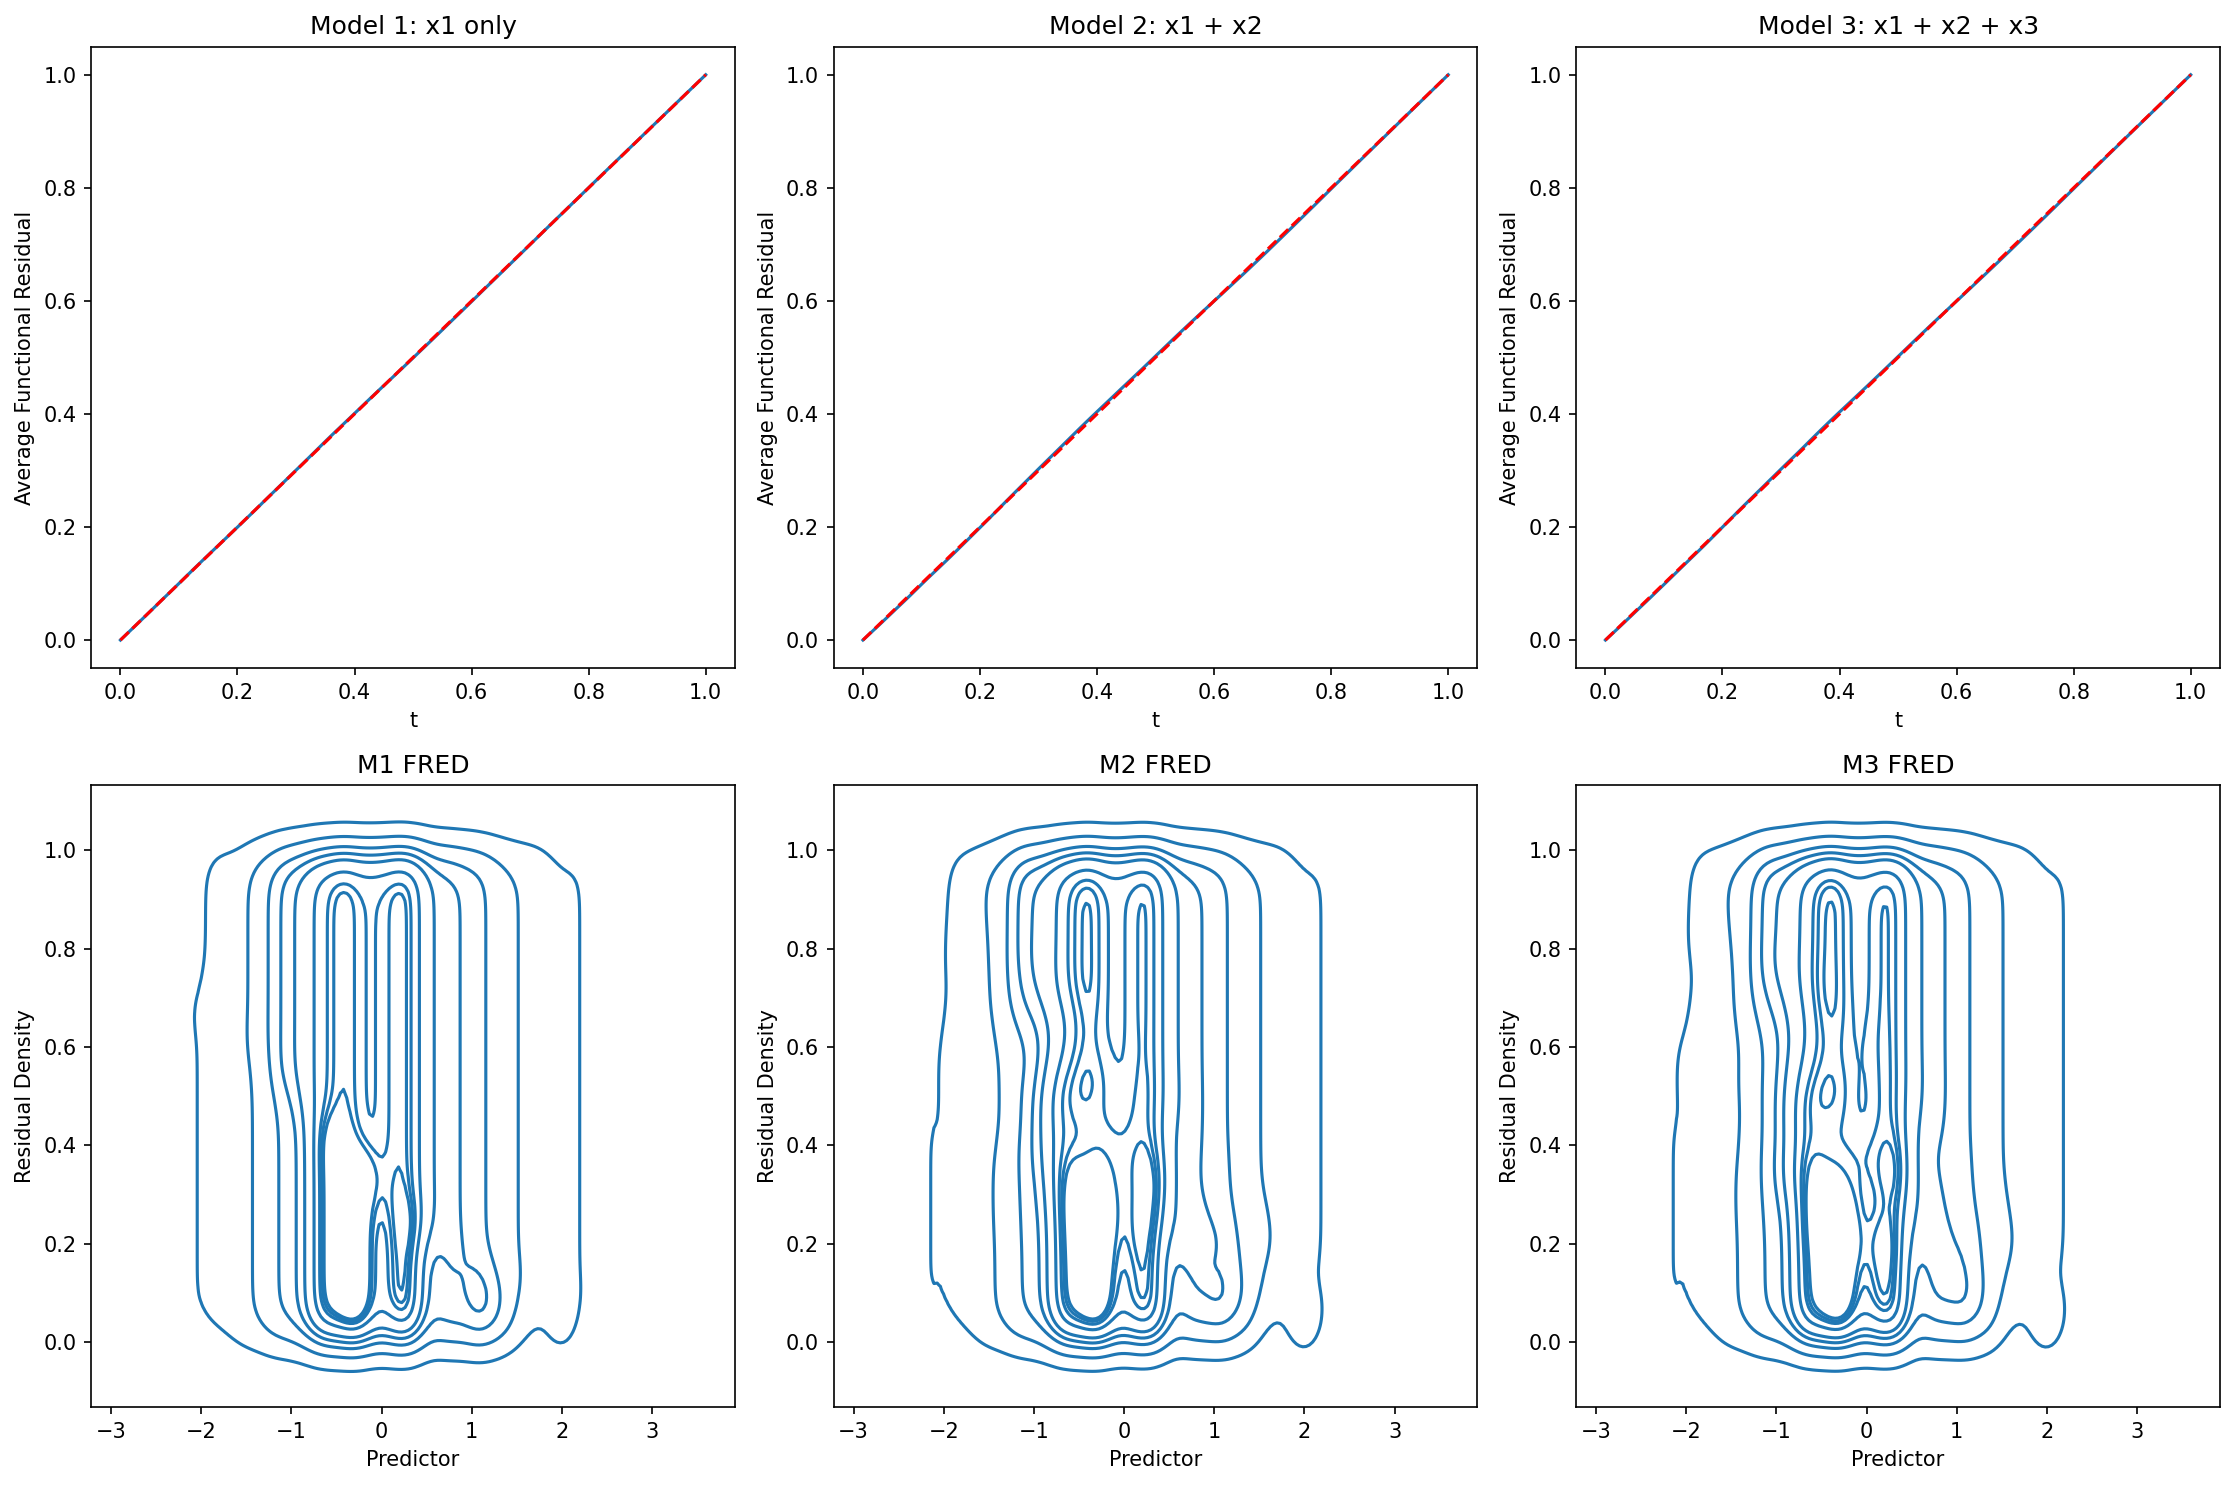

In [8]:
# Generate data
np.random.seed(333)
n = 800
x1 = np.random.normal(size=n)
x2 = np.random.normal(size=n)
x3 = np.random.normal(size=n)

# True model includes x1 and x2, but not x3
eta = 1 + x1 + 0.5*x2
y = np.random.binomial(1, 1/(1 + np.exp(-eta)))

# Fit models
X1 = sm.add_constant(x1)
X2 = sm.add_constant(np.column_stack([x1, x2]))
X3 = sm.add_constant(np.column_stack([x1, x2, x3]))

model1 = sm.GLM(y, X1, family=sm.families.Binomial()).fit()
model2 = sm.GLM(y, X2, family=sm.families.Binomial()).fit()
model3 = sm.GLM(y, X3, family=sm.families.Binomial()).fit()

# Visual comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

ffplot(model1, ax=axes[0, 0])
axes[0, 0].set_title("Model 1: x1 only")

ffplot(model2, ax=axes[0, 1])
axes[0, 1].set_title("Model 2: x1 + x2")

ffplot(model3, ax=axes[0, 2])
axes[0, 2].set_title("Model 3: x1 + x2 + x3")

fredplot(model1, x1, type="kde", ax=axes[1, 0])
axes[1, 0].set_title("M1 FRED")

fredplot(model2, x1, type="kde", ax=axes[1, 1])
axes[1, 1].set_title("M2 FRED")

fredplot(model3, x1, type="kde", ax=axes[1, 2])
axes[1, 2].set_title("M3 FRED")

plt.tight_layout()
plt.show()

---

## Example 6: customizing plots

### Styling with Matplotlib

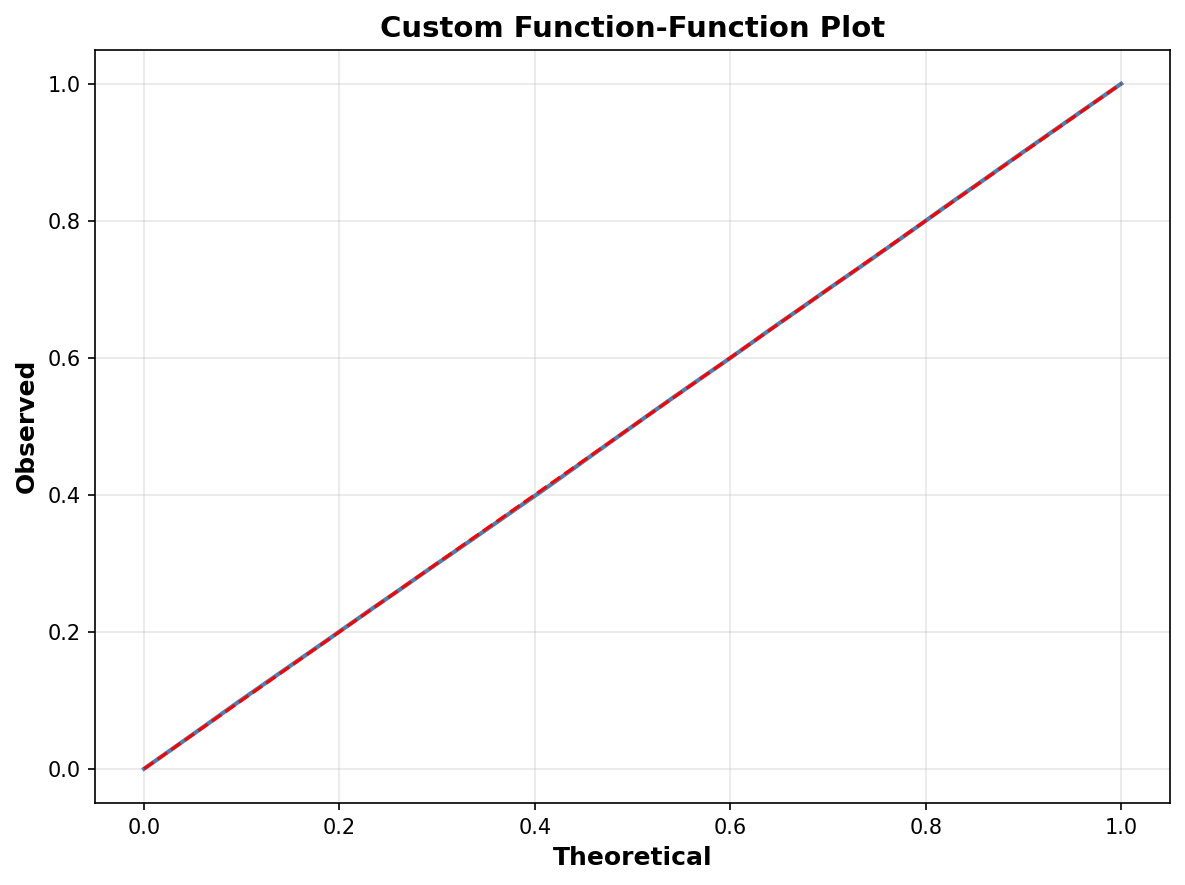

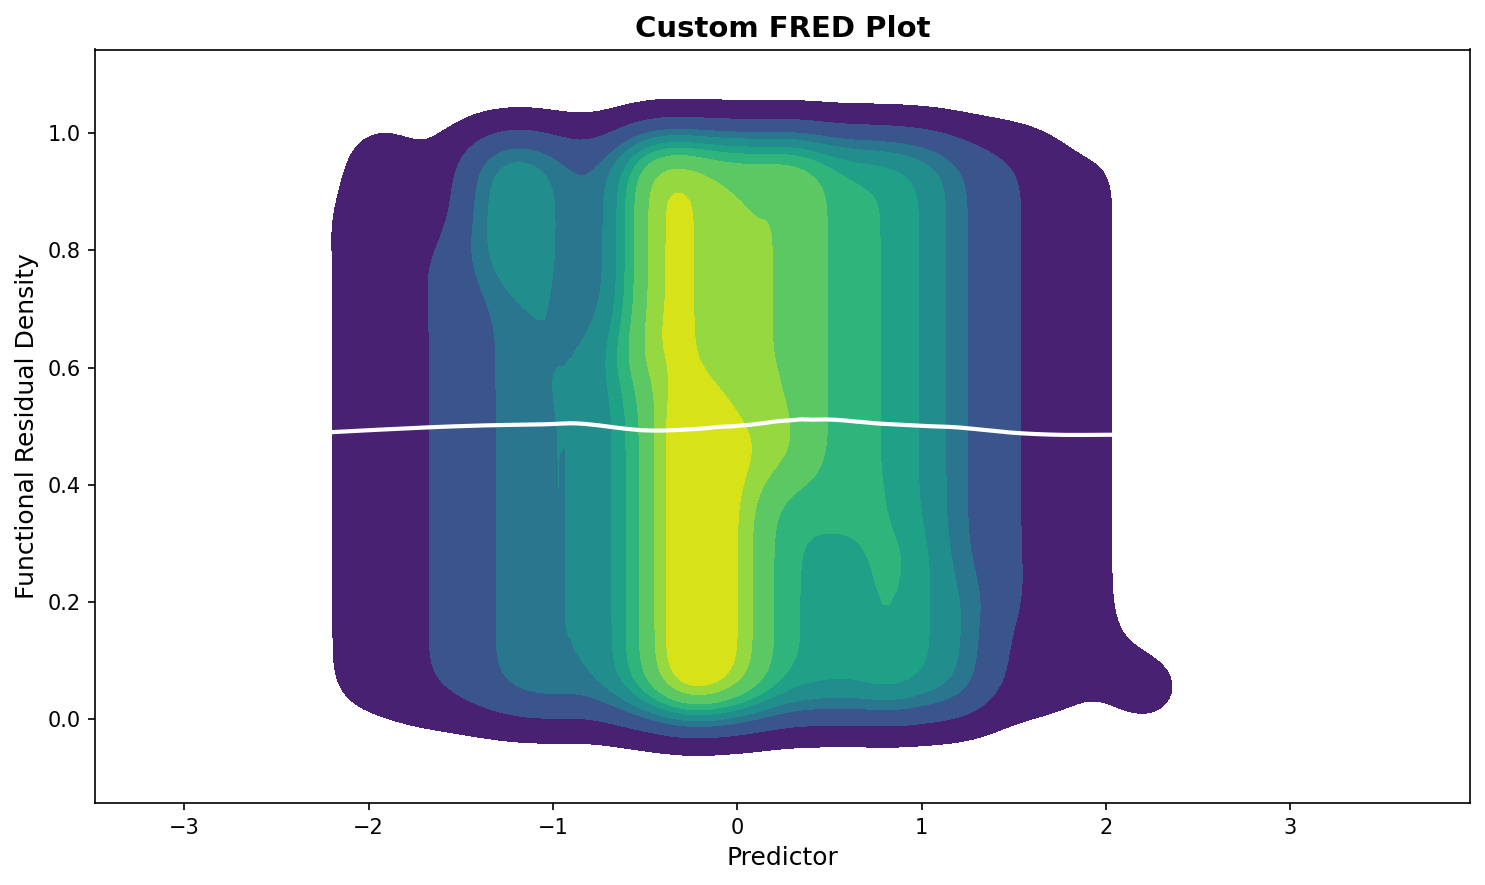

In [9]:
# Fit a model
np.random.seed(100)
n = 500
x = np.random.normal(size=n)
y = np.random.binomial(1, 1/(1 + np.exp(-x)))
X = sm.add_constant(x)
model = sm.GLM(y, X, family=sm.families.Binomial()).fit()

# Customize ffplot
fig, ax = plt.subplots(figsize=(8, 6))
ffplot(model, ax=ax, color='steelblue', linewidth=2)
ax.set_xlabel("Theoretical", fontsize=12, fontweight='bold')
ax.set_ylabel("Observed", fontsize=12, fontweight='bold')
ax.set_title("Custom Function-Function Plot",
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Customize fredplot
fig, ax = plt.subplots(figsize=(10, 6))
fredplot(model, x, type="kde", ax=ax,
         lowess=True, frac=0.5,
         fill=True, cmap='viridis')
ax.set_xlabel("Predictor", fontsize=12)
ax.set_ylabel("Functional Residual Density", fontsize=12)
ax.set_title("Custom FRED Plot", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Using Seaborn themes

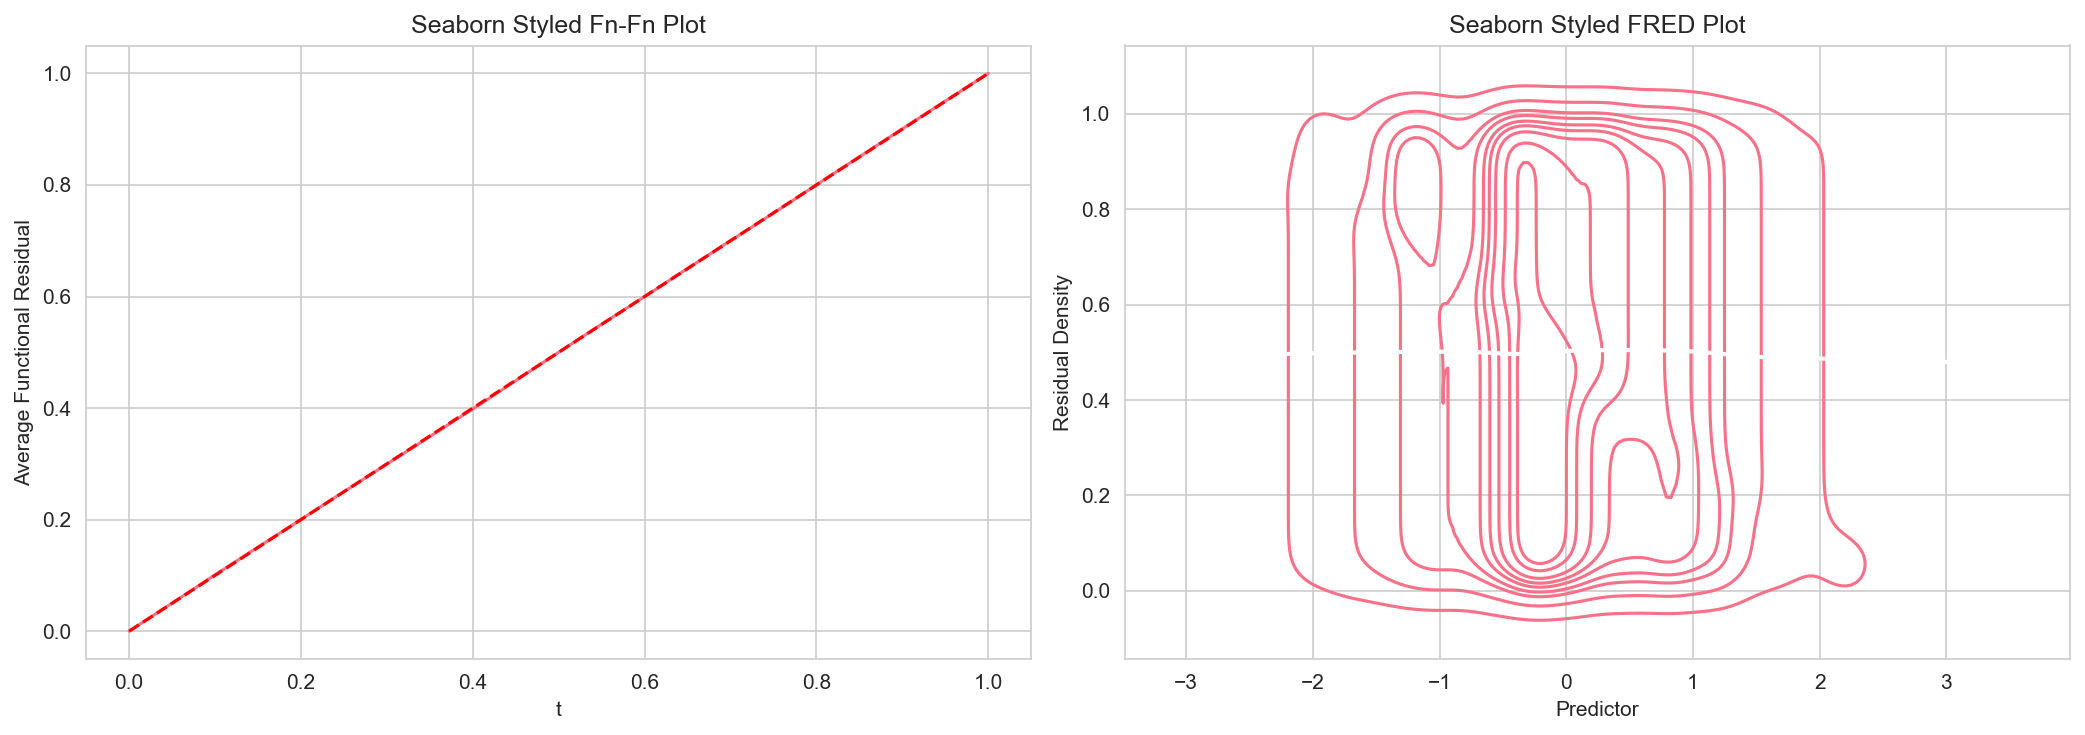

In [10]:
import seaborn as sns

# Set seaborn style
sns.set_style("whitegrid")
sns.set_palette("husl")

# Create plots with seaborn styling
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ffplot(model, ax=axes[0])
axes[0].set_title("Seaborn Styled Fn-Fn Plot", fontsize=12)

fredplot(model, x, type="kde", ax=axes[1], lowess=True)
axes[1].set_title("Seaborn Styled FRED Plot", fontsize=12)

plt.tight_layout()
plt.show()

# Reset to default
sns.reset_defaults()

---

## Example 7: large datasets

### Efficient handling of big data

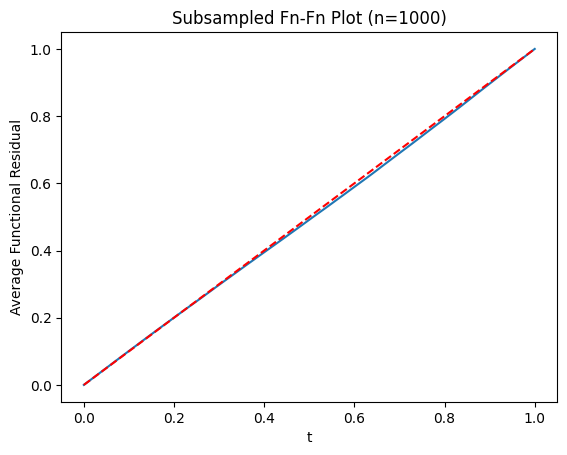

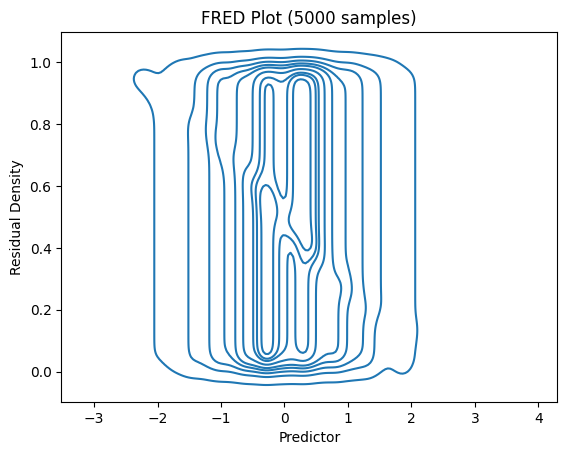

In [11]:
# Large dataset
np.random.seed(12345)
n = 50000
x_large = np.random.normal(size=n)
y_large = np.random.binomial(1, 1/(1 + np.exp(-x_large)))
X_large = sm.add_constant(x_large)
model_large = sm.GLM(y_large, X_large, family=sm.families.Binomial()).fit()

# Use subsampling for faster plotting
ffplot(model_large, n=1000)
plt.title("Subsampled Fn-Fn Plot (n=1000)")
plt.show()

# For FRED plots, use subsampling
fredplot(model_large, x_large, type="kde", n=5000)
plt.title("FRED Plot (5000 samples)")
plt.show()

---

## Example 8: diagnostic workflow

### Complete model checking procedure

/Users/greenwbm/Dropbox/devel/unifres/python/.venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


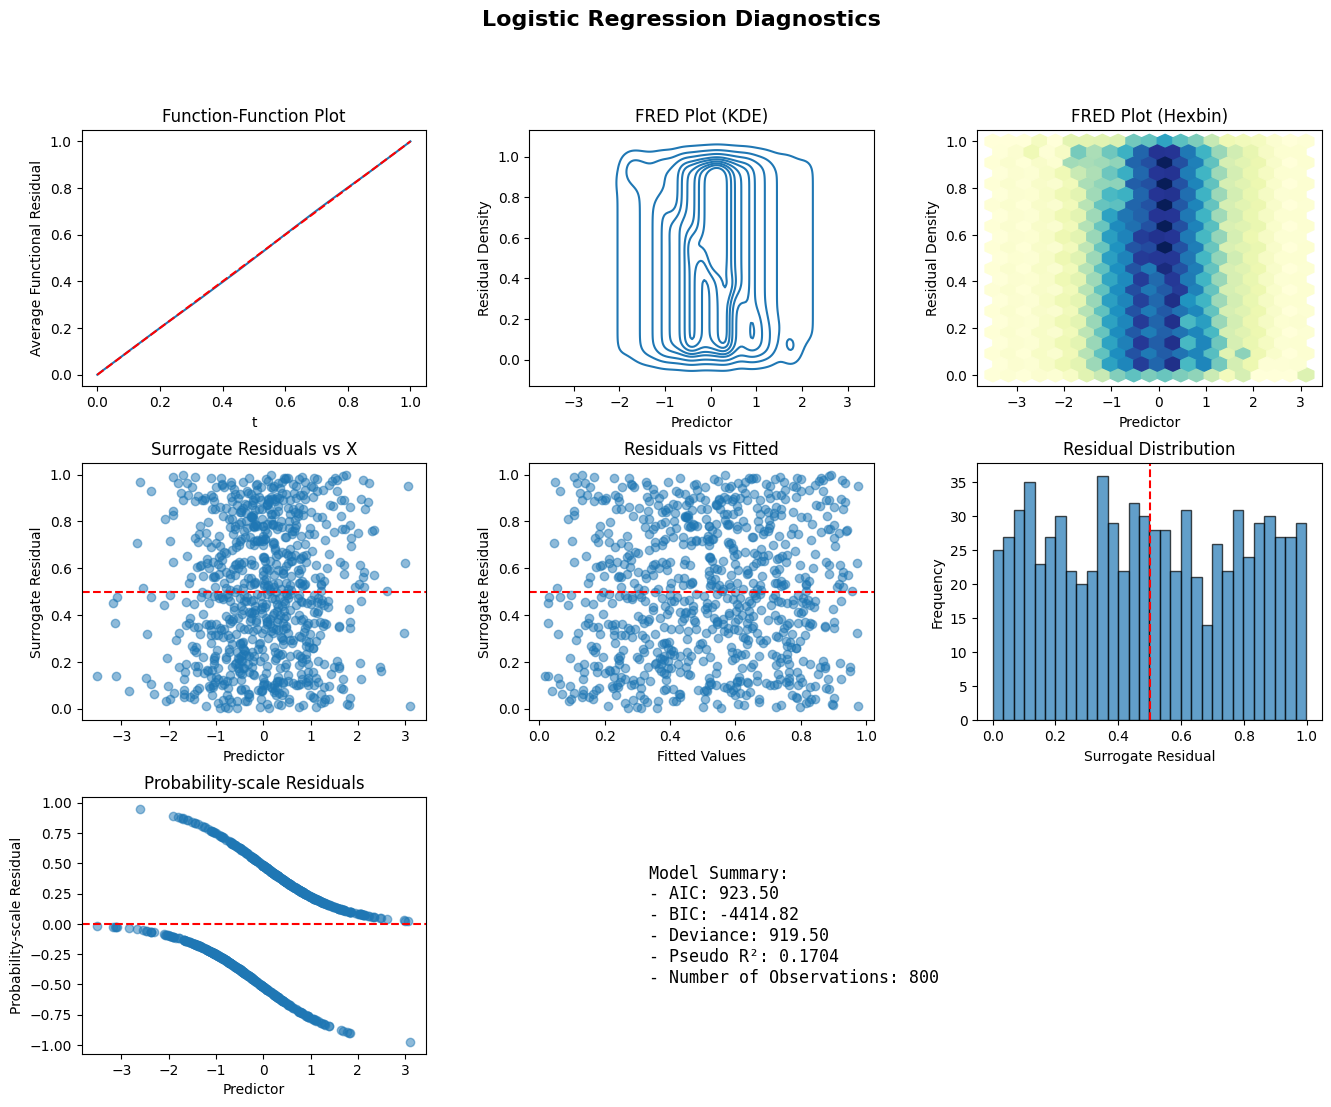

In [12]:
def diagnostic_panel(model, x, title="Model Diagnostics"):
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    ax1 = fig.add_subplot(gs[0, 0])
    ffplot(model, ax=ax1)
    ax1.set_title("Function-Function Plot")

    ax2 = fig.add_subplot(gs[0, 1])
    fredplot(model, x, type="kde", ax=ax2)
    ax2.set_title("FRED Plot (KDE)")

    ax3 = fig.add_subplot(gs[0, 2])
    fredplot(model, x, type="hex", ax=ax3)
    ax3.set_title("FRED Plot (Hexbin)")

    ax4 = fig.add_subplot(gs[1, 0])
    surr_res = fresiduals(model, type="surrogate")
    ax4.scatter(x, surr_res, alpha=0.5)
    ax4.axhline(y=0.5, color='r', linestyle='--')
    ax4.set_xlabel("Predictor")
    ax4.set_ylabel("Surrogate Residual")
    ax4.set_title("Surrogate Residuals vs X")

    ax5 = fig.add_subplot(gs[1, 1])
    ax5.scatter(model.fittedvalues, surr_res, alpha=0.5)
    ax5.axhline(y=0.5, color='r', linestyle='--')
    ax5.set_xlabel("Fitted Values")
    ax5.set_ylabel("Surrogate Residual")
    ax5.set_title("Residuals vs Fitted")

    ax6 = fig.add_subplot(gs[1, 2])
    ax6.hist(surr_res, bins=30, edgecolor='black', alpha=0.7)
    ax6.axvline(x=0.5, color='r', linestyle='--')
    ax6.set_xlabel("Surrogate Residual")
    ax6.set_ylabel("Frequency")
    ax6.set_title("Residual Distribution")

    ax7 = fig.add_subplot(gs[2, 0])
    prob_res = fresiduals(model, type="probscale")
    ax7.scatter(x, prob_res, alpha=0.5)
    ax7.axhline(y=0, color='r', linestyle='--')
    ax7.set_xlabel("Predictor")
    ax7.set_ylabel("Probability-scale Residual")
    ax7.set_title("Probability-scale Residuals")

    ax8 = fig.add_subplot(gs[2, 1:])
    ax8.axis('off')
    summary_text = f"""
    Model Summary:
    - AIC: {model.aic:.2f}
    - BIC: {model.bic:.2f}
    - Deviance: {model.deviance:.2f}
    - Pseudo R²: {1 - model.deviance/model.null_deviance:.4f}
    - Number of Observations: {model.nobs:.0f}
    """
    ax8.text(0.1, 0.5, summary_text, fontsize=12,
             verticalalignment='center', family='monospace')

    fig.suptitle(title, fontsize=16, fontweight='bold')
    plt.show()

np.random.seed(999)
n = 800
x_diag = np.random.normal(size=n)
y_diag = np.random.binomial(1, 1/(1 + np.exp(-x_diag)))
X_diag = sm.add_constant(x_diag)
model_diag = sm.GLM(y_diag, X_diag, family=sm.families.Binomial()).fit()
diagnostic_panel(model_diag, x_diag, title="Logistic Regression Diagnostics")

---

## Next steps

- Explore [R Examples](examples-r.qmd) for R-specific implementations
- Learn about the [Methodology](methodology.qmd) behind functional residuals
- Check the [Python API Reference](reference_python/index.qmd) for detailed function documentation